# Modelización — Dataset de Sentimiento (Amazon Reviews ES)

Clasificación binaria de sentimiento (**negativo** vs **positivo**) sobre el corpus completo de 200,000 reseñas.

In [1]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                              precision_score, recall_score, roc_auc_score,
                              confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#E24B4A', '#639922']

## 1. Carga de datos y mapeo binario de sentimiento

In [2]:
print('--- Cargando SetFit/amazon_reviews_multi_es desde Hugging Face ---')
dataset = load_dataset('SetFit/amazon_reviews_multi_es')
df = pd.DataFrame(dataset['train'])
df = df.rename(columns={'text': 'review_body', 'label': 'stars'})
print('Filas:', len(df))
print('Columnas:', df.columns.tolist())
df.head(3)

--- Cargando SetFit/amazon_reviews_multi_es desde Hugging Face ---


Repo card metadata block was not found. Setting CardData to empty.


Filas: 200000
Columnas: ['id', 'review_body', 'stars', 'label_text']


,id,review_body,stars,label_text
0,es_0491108,Nada bueno se me fue ka pantalla en menos de 8...,0,0
1,es_0869872,"Horrible, nos tuvimos que comprar otro porque ...",0,0
2,es_0811721,Te obligan a comprar dos unidades y te llega s...,0,0


In [3]:
def map_sentiment(stars):
    if stars <= 3:
        return 'negativo'
    else:
        return 'positivo'

df['sentimiento'] = df['stars'].apply(map_sentiment)
print(df['sentimiento'].value_counts())
print(df['sentimiento'].value_counts(normalize=True).round(3) * 100)

sentimiento
negativo    160000
positivo     40000
Name: count, dtype: int64
sentimiento
negativo    80.0
positivo    20.0
Name: proportion, dtype: float64


## 2. Preprocesamiento de texto

Se reutiliza la cadena de limpieza propuesta en la Sección 4.1 del informe: minúsculas, eliminación de caracteres no alfabéticos, stopwords en español, filtrado de tokens cortos.

In [4]:
STOPWORDS_ES = {
    'de','la','el','en','y','a','que','los','se','del','las','un','por',
    'una','con','no','es','su','al','lo','mas','pero','si','como','me',
    'le','mi','muy','este','esta','ya','tambien','hay','para','son','fue',
    'todo','bien','cuando','sobre','sin','han','he','o','e','ni',
    'era','ser','tiene','habia','sus','mismo','tan','asi',
    'unos','desde','porque','hasta','te','les','nos','yo','tu','tus'
}

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-zñáéíóú ]', ' ', texto)
    palabras = [w for w in texto.split() if w not in STOPWORDS_ES and len(w) > 2]
    return ' '.join(palabras)

t0 = time.time()
df['texto_limpio'] = df['review_body'].apply(limpiar_texto)
print(f'Preprocesamiento completado en {time.time()-t0:.1f}s')
df[['review_body', 'texto_limpio', 'sentimiento']].head(3)

Preprocesamiento completado en 1.6s


,review_body,texto_limpio,sentimiento
0,Nada bueno se me fue ka pantalla en menos de 8...,nada bueno pantalla menos meses recibido respu...,negativo
1,"Horrible, nos tuvimos que comprar otro porque ...",horrible tuvimos comprar otro nosotros sabemos...,negativo
2,Te obligan a comprar dos unidades y te llega s...,obligan comprar dos unidades llega solo forma ...,negativo


## 3. División train/test y vectorización TF-IDF

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['texto_limpio'], df['sentimiento'],
    test_size=0.2, stratify=df['sentimiento'], random_state=RANDOM_STATE
)

print('Train:', X_train_text.shape[0], '| Test:', X_test_text.shape[0])

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=5)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print('Dimensión de la matriz TF-IDF (train):', X_train.shape)

Train: 160000 | Test: 40000


Dimensión de la matriz TF-IDF (train): (160000, 30000)


## 4. Entrenamiento de modelos

Se entrenan cuatro modelos con manejo explícito del desbalance de clases.

In [6]:
y_train_bin = (y_train == 'positivo').astype(int).to_numpy()
y_test_bin = (y_test == 'positivo').astype(int).to_numpy()

modelos = {}

modelos['Regresión Logística'] = LogisticRegression(
    class_weight='balanced', max_iter=1000, solver='saga', n_jobs=-1, random_state=RANDOM_STATE
)

modelos['Naive Bayes Multinomial'] = MultinomialNB()

modelos['SVM Lineal'] = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', random_state=RANDOM_STATE), cv=3
)

neg, pos = (y_train_bin == 0).sum(), (y_train_bin == 1).sum()
modelos['XGBoost'] = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=neg / pos, eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    t0 = time.time()
    modelo.fit(X_train, y_train_bin)
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else modelo.decision_function(X_test)
    tiempo = time.time() - t0

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test_bin, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test_bin, y_pred),
        'F1-macro': f1_score(y_test_bin, y_pred, average='macro'),
        'Precision (positivo)': precision_score(y_test_bin, y_pred),
        'Recall (positivo)': recall_score(y_test_bin, y_pred),
        'ROC-AUC': roc_auc_score(y_test_bin, y_proba),
        'Tiempo entrenamiento (s)': round(tiempo, 1)
    })
    predicciones[nombre] = y_pred
    print(f'{nombre}: listo en {tiempo:.1f}s')

df_resultados = pd.DataFrame(resultados).sort_values('F1-macro', ascending=False).reset_index(drop=True)
df_resultados

Regresión Logística: listo en 1.4s
Naive Bayes Multinomial: listo en 0.0s


SVM Lineal: listo en 2.8s


XGBoost: listo en 136.7s


,Modelo,Accuracy,Balanced Accuracy,F1-macro,Precision (positivo),Recall (positivo),ROC-AUC,Tiempo entrenamiento (s)
0,Regresión Logística,0.816250,0.811703,0.756742,0.526604,0.804125,0.885541,1.4
1,XGBoost,0.797225,0.774266,0.728608,0.495331,0.736000,0.858447,136.7
2,SVM Lineal,0.841725,0.680672,0.707930,0.669373,0.412250,0.874540,2.8
3,Naive Bayes Multinomial,0.834625,0.649984,0.677745,0.669274,0.342250,0.876402,0.0


## 5. Validación cruzada estratificada (5 pliegues)

Para los modelos lineales más rápidos de re-entrenar se valida la estabilidad del rendimiento.

In [7]:
cv_modelos = {
    'Regresión Logística': LogisticRegression(class_weight='balanced', max_iter=1000, solver='saga', n_jobs=-1, random_state=RANDOM_STATE),
    'Naive Bayes Multinomial': MultinomialNB(),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_resultados = []

for nombre, modelo in cv_modelos.items():
    t0 = time.time()
    scores = cross_validate(modelo, X_train, y_train_bin, cv=skf,
                             scoring=['balanced_accuracy', 'f1_macro'], n_jobs=-1)
    cv_resultados.append({
        'Modelo': nombre,
        'Balanced Accuracy (CV, media)': scores['test_balanced_accuracy'].mean(),
        'Balanced Accuracy (CV, std)': scores['test_balanced_accuracy'].std(),
        'F1-macro (CV, media)': scores['test_f1_macro'].mean(),
        'F1-macro (CV, std)': scores['test_f1_macro'].std(),
        'Tiempo (s)': round(time.time() - t0, 1)
    })
    print(f'{nombre}: CV listo en {time.time()-t0:.1f}s')

df_cv = pd.DataFrame(cv_resultados)
df_cv

Regresión Logística: CV listo en 6.4s


Naive Bayes Multinomial: CV listo en 3.4s


,Modelo,"Balanced Accuracy (CV, media)","Balanced Accuracy (CV, std)","F1-macro (CV, media)","F1-macro (CV, std)",Tiempo (s)
0,Regresión Logística,0.805883,0.001878,0.753738,0.001798,6.4
1,Naive Bayes Multinomial,0.646324,0.002532,0.674261,0.003071,3.4


## 6. Matrices de confusión

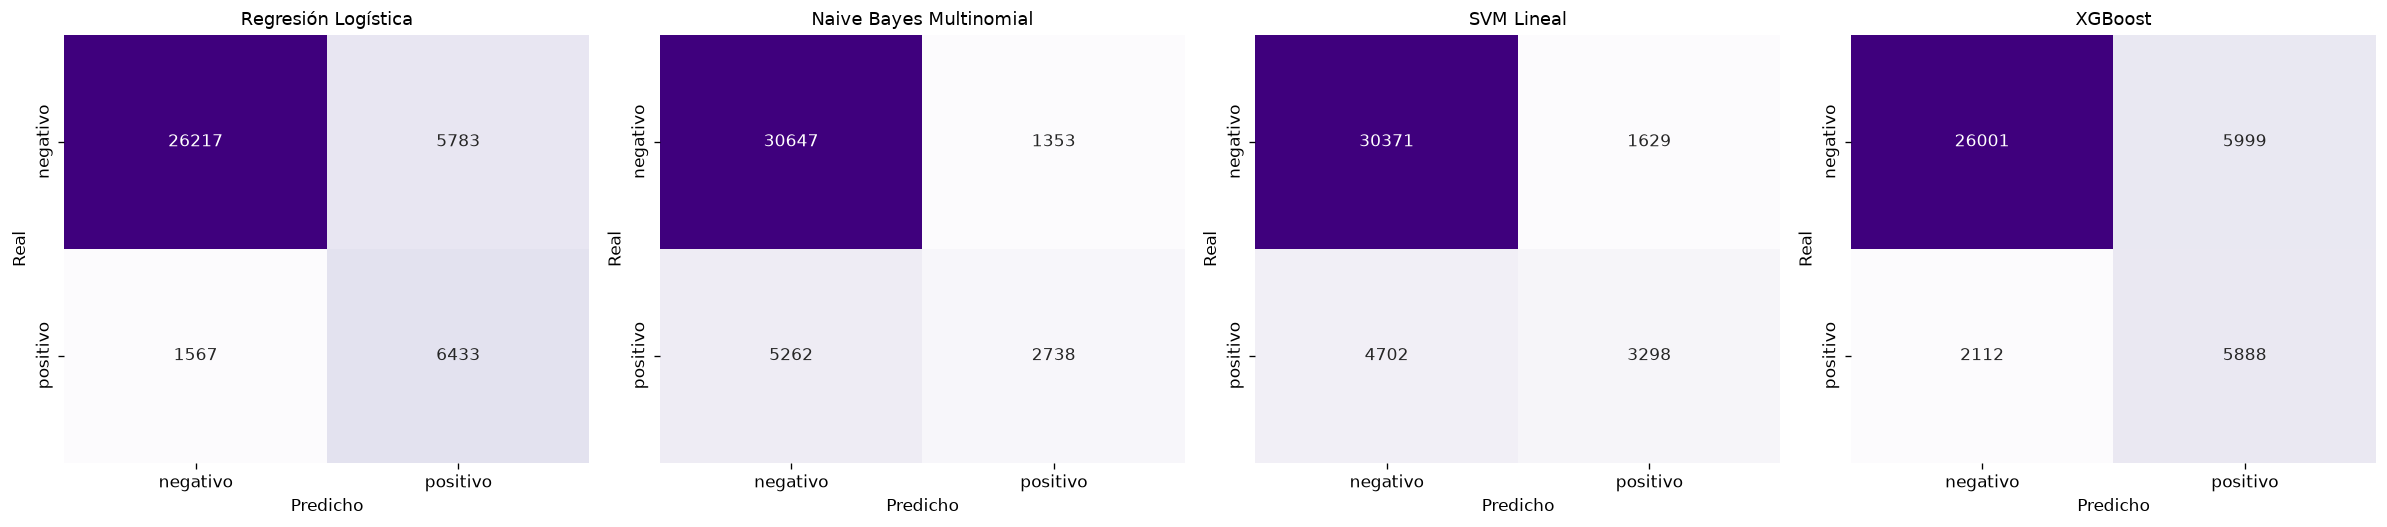

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
                xticklabels=['negativo', 'positivo'], yticklabels=['negativo', 'positivo'])
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('../resultados/figuras/fig9_matrices_confusion_amazon.png', bbox_inches='tight')
plt.show()

## 7. Comparación gráfica de modelos

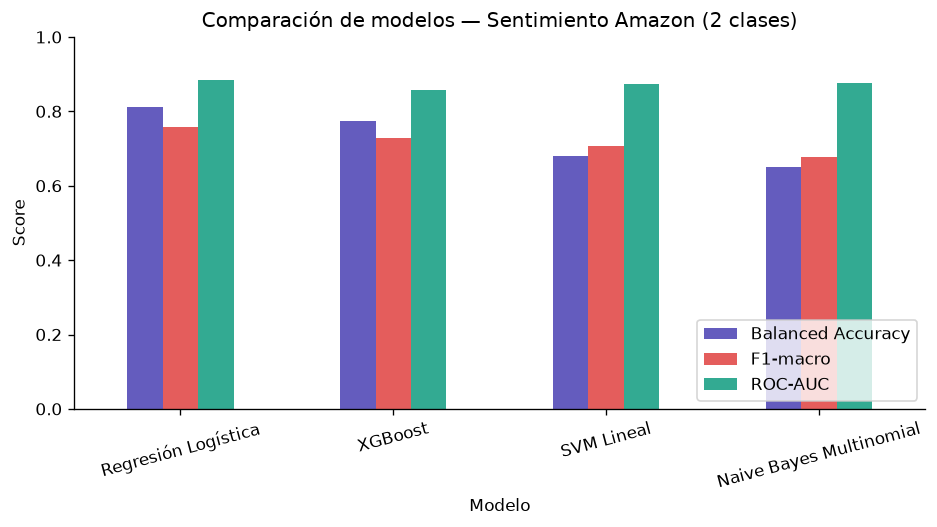

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
metricas_plot = df_resultados.set_index('Modelo')[['Balanced Accuracy', 'F1-macro', 'ROC-AUC']]
metricas_plot.plot(kind='bar', ax=ax, color=['#534AB7', '#E24B4A', '#1DA186'], alpha=0.9)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparación de modelos — Sentimiento Amazon (2 clases)')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../resultados/figuras/fig10_comparacion_modelos_amazon.png', bbox_inches='tight')
plt.show()

## 8. Exportar resultados

In [10]:
df_resultados.to_csv('../resultados/tablas/resultados_amazon.csv', index=False)
df_cv.to_csv('../resultados/tablas/resultados_cv_amazon.csv', index=False)
print('Resultados guardados: resultados_amazon.csv, resultados_cv_amazon.csv')

Resultados guardados: resultados_amazon.csv, resultados_cv_amazon.csv


## 9. Curvas de aprendizaje (train vs. cross-validation)

Se evalúa el desempeño en función del tamaño del conjunto de entrenamiento para los modelos rápidos de re-entrenar (Regresión Logística, Naive Bayes, SVM Lineal). Se excluye XGBoost de este análisis por su alto costo computacional al re-entrenarse múltiples veces sobre fracciones crecientes del dataset completo (200,000 filas).

Regresion Logistica : listo en 7.8 s


Naive Bayes Multinomial : listo en 0.3 s


SVM Lineal : listo en 3.3 s


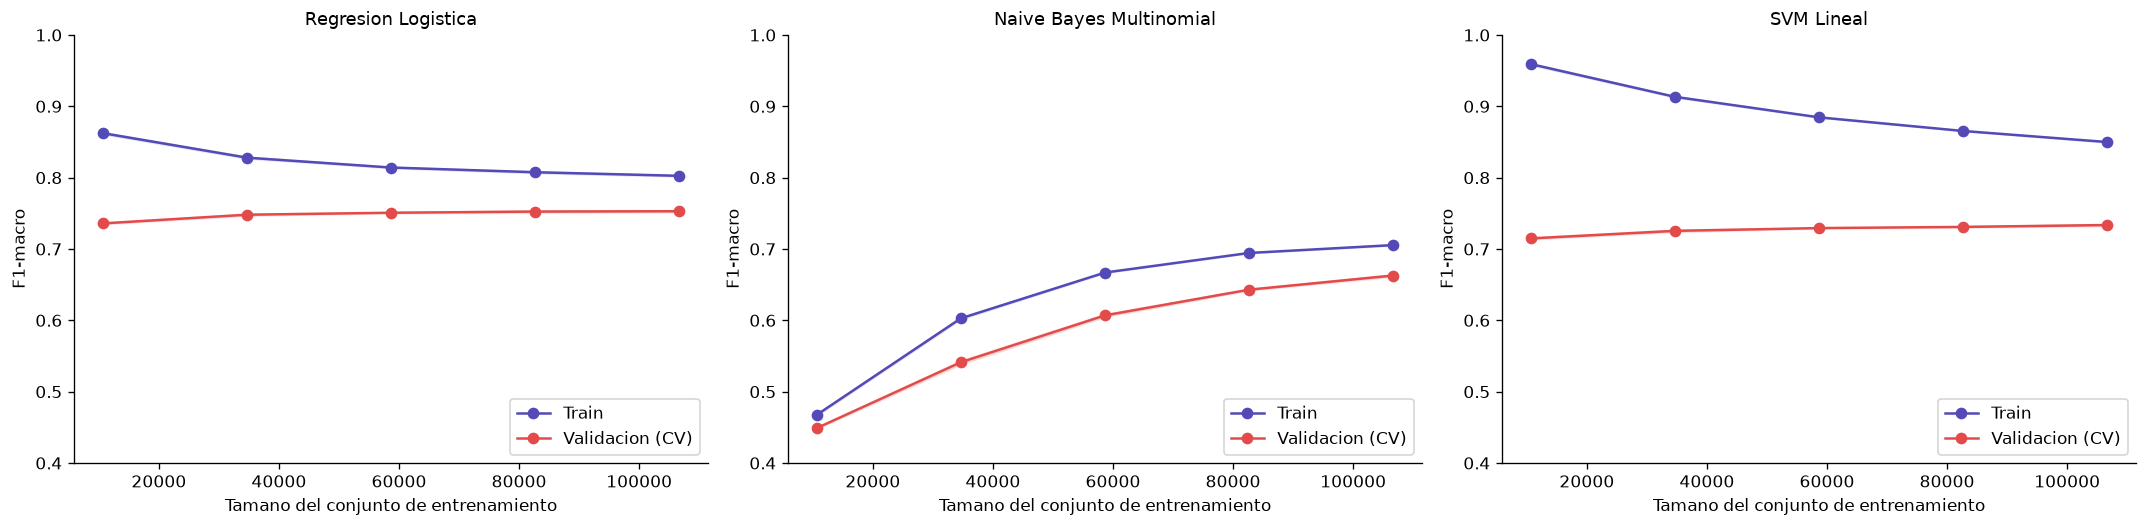

In [11]:
from sklearn.model_selection import learning_curve

modelos_lc = {
    'Regresion Logistica': LogisticRegression(class_weight='balanced', max_iter=1000, solver='saga', n_jobs=-1, random_state=RANDOM_STATE),
    'Naive Bayes Multinomial': MultinomialNB(),
    'SVM Lineal': LinearSVC(class_weight='balanced', random_state=RANDOM_STATE),
}

train_sizes = np.linspace(0.1, 1.0, 5)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, (nombre, modelo) in zip(axes, modelos_lc.items()):
    t0 = time.time()
    sizes, train_scores, val_scores = learning_curve(
        modelo, X_train, y_train_bin, train_sizes=train_sizes, cv=3,
        scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE
    )
    ax.plot(sizes, train_scores.mean(axis=1), 'o-', color='#534AB7', label='Train')
    ax.plot(sizes, val_scores.mean(axis=1), 'o-', color='#E24B4A', label='Validacion (CV)')
    ax.fill_between(sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='#534AB7')
    ax.fill_between(sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='#E24B4A')
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Tamano del conjunto de entrenamiento')
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0.4, 1.0)
    ax.legend(loc='lower right')
    print(nombre, ': listo en', round(time.time()-t0, 1), 's')

plt.tight_layout()
plt.savefig('../resultados/figuras/fig16_curvas_aprendizaje_amazon.png', bbox_inches='tight')
plt.show()